In [ ]:
# Basic data manipulation and modeling libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [ ]:
df = pd.read_csv('Consulting_survey_DataSet (3).csv')


In [ ]:
# Renaming the columns to shorter and easier-to-use names
df.columns = [
    'timestamp',
    'current_consulting_firm',
    'current_firm',
    'current_practice',
    'current_title',
    'current_country',
    'current_compensation_usd',
    'estimated_bonus_usd_2021',
    'expected_total_compensation',
    'weekly_hours',
    'offer_received',
    'offer_from_consulting_firm',
    'highest_offer_firm',
    'offer_practice',
    'offered_title',
    'offer_country',
    'highest_offer_compensation_usd',
    'highest_offer_bonus_usd',
    'accepted_offer'
]


print(df.columns.tolist())


['timestamp', 'current_consulting_firm', 'current_firm', 'current_practice', 'current_title', 'current_country', 'current_compensation_usd', 'estimated_bonus_usd_2021', 'expected_total_compensation', 'weekly_hours', 'offer_received', 'offer_from_consulting_firm', 'highest_offer_firm', 'offer_practice', 'offered_title', 'offer_country', 'highest_offer_compensation_usd', 'highest_offer_bonus_usd', 'accepted_offer']


In [ ]:
# Helper function to convert hour ranges to numeric averages
def hours_to_numeric(hours_str):
    if isinstance(hours_str, str) and '-' in hours_str:
        low, high = map(int, hours_str.split('-'))
        return (low + high) / 2
    return 0  # Use 0 or NaN if the format is unexpected

df['weekly_hours_numeric'] = df['weekly_hours'].apply(hours_to_numeric)


In [ ]:
df['weekly_hours_numeric'].value_counts()

,count
weekly_hours_numeric,
44.5,1767
54.5,1362
64.5,595
0.0,347
74.5,129


In [ ]:
# Convert "offer_received" to binary (1 if "Yes", else 0)
df['offer_received_binary'] = df['offer_received'].apply(lambda x: 1 if x == 'Yes' else 0)


In [ ]:
df['offer_received_binary'].value_counts()

,count
offer_received_binary,
0,3088
1,1112


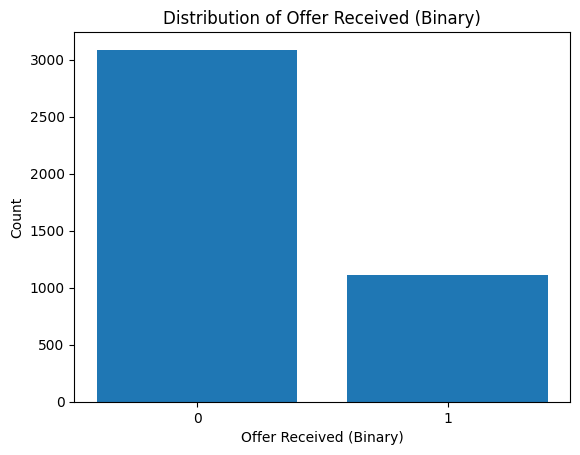

In [ ]:
# Get the value counts for the 'offer_received_binary' column
counts = df['offer_received_binary'].value_counts()

# Create the bar chart
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel('Offer Received (Binary)')
plt.ylabel('Count')
plt.title('Distribution of Offer Received (Binary)')
plt.show()

In [ ]:
# Define columns to encode
categorical_columns = [
    'current_consulting_firm',
    'current_practice',
    'current_title',
    'current_country'
]


for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))



In [ ]:
# Define features and target variable
features = df[['current_compensation_usd',
               'estimated_bonus_usd_2021',
               'expected_total_compensation',
               'weekly_hours_numeric',
               'offer_received_binary'] + categorical_columns]


target = df['offer_received_binary']



In [ ]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)


In [ ]:
# Initialize the scaler and apply it to the training and test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Define models with class balancing if needed
models = {
    "Logistic Regression": LogisticRegression(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Support Vector Machine": SVC(random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced')
}


In [ ]:
# Dictionary to store model performance
model_performance = {}

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict on test data
    y_pred = model.predict(X_test_scaled)

    # Collect performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)


    model_performance[model_name] = {
        "Accuracy": accuracy,
        "Classification Report": report
    }

model_performance


{'Logistic Regression': {'Accuracy': 1.0,
  'Classification Report': {'0': {'precision': 1.0,
    'recall': 1.0,
    'f1-score': 1.0,
    'support': 632.0},
   '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 208.0},
   'accuracy': 1.0,
   'macro avg': {'precision': 1.0,
    'recall': 1.0,
    'f1-score': 1.0,
    'support': 840.0},
   'weighted avg': {'precision': 1.0,
    'recall': 1.0,
    'f1-score': 1.0,
    'support': 840.0}}},
 'Random Forest': {'Accuracy': 1.0,
  'Classification Report': {'0': {'precision': 1.0,
    'recall': 1.0,
    'f1-score': 1.0,
    'support': 632.0},
   '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 208.0},
   'accuracy': 1.0,
   'macro avg': {'precision': 1.0,
    'recall': 1.0,
    'f1-score': 1.0,
    'support': 840.0},
   'weighted avg': {'precision': 1.0,
    'recall': 1.0,
    'f1-score': 1.0,
    'support': 840.0}}},
 'Support Vector Machine': {'Accuracy': 0.9976190476190476,
  'Classification Report': {'0': {

In [ ]:
# Cross-validate each model and store average scores
for model_name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)  # 5-fold cross-validation
    print(f"{model_name} - Cross-Validation Accuracy: {scores.mean():.4f}")


Logistic Regression - Cross-Validation Accuracy: 1.0000
Random Forest - Cross-Validation Accuracy: 1.0000
Support Vector Machine - Cross-Validation Accuracy: 0.9988
Decision Tree - Cross-Validation Accuracy: 1.0000


In [ ]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
print("Best parameters for Random Forest:", grid_search.best_params_)
print("Best cross-validated accuracy:", grid_search.best_score_)


Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validated accuracy: 1.0


In [ ]:
# Predict and evaluate on the test set with the best model
best_model = grid_search.best_estimator_
y_test_pred = best_model.predict(X_test_scaled)
print("Test Set Performance:\n", classification_report(y_test, y_test_pred))


Test Set Performance:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       632
           1       1.00      1.00      1.00       208

    accuracy                           1.00       840
   macro avg       1.00      1.00      1.00       840
weighted avg       1.00      1.00      1.00       840

